Tarea 1: Demographic Profile & Migration Landscape
IELE756 – Preparación y Análisis de Datos
Comuna analizada: Puente Alto

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

Tarea 1: Demographic Profile & Migration Landscape
En este notebook se construye un perfil demográfico y migratorio de la comuna
de Puente Alto utilizando los microdatos del Censo 2024. El análisis incluye:
carga y unión de tablas, indicadores demográficos, visualizaciones de migración,
mapas coropléticos y una tabla resumen a nivel comunal.


In [2]:
BASE = "/Users/martingomez/Downloads/viv_hog_per_censo2024"

Se cargan las tres tablas principales del Censo 2024: viviendas, hogares y personas. Además, se seleccionan únicamente las variables relevantes para el análisis, con el objetivo de optimizar el uso de memoria y facilitar el procesamiento posterior.
Se filtran los datos correspondientes a la comuna de Puente Alto, con el objetivo de enfocar el análisis en esta unidad territorial específica.

In [3]:
vivienda = pd.read_parquet(
    f"{BASE}/viviendas_censo2024.parquet",
    columns=[
        "id_vivienda",
        "region",
        "comuna",
        "p4a_mat_paredes"])

hogar = pd.read_parquet(
    f"{BASE}/hogares_censo2024.parquet",
    columns=[
        "id_vivienda",
        "id_hogar",
        "p12_tenencia_viv",
        "tipologia_hogar"])

persona = pd.read_parquet(
    f"{BASE}/personas_censo2024.parquet",
    columns=[
        "id_vivienda",
        "id_hogar",
        "id_persona",
        "sexo",
        "edad",
        "p27_nacionalidad_esp",
        "p25_lug_nacimiento_rec",
        "p24_lug_resid5",
        "p25_lug_nacimiento",
        "p26_llegada_periodo",
        "escolaridad",
        "cine11",
        "sit_fuerza_trabajo",
        "cod_ciuo",
        "cod_caenes",
        "p45_medio_transporte",
        "comuna",
        "region"])

Se combinan las tablas de personas, hogares y viviendas mediante sus identificadores comunes, construyendo una base consolidada a nivel individual.

In [4]:
print("VIVIENDA:", vivienda.shape)
print("HOGAR:", hogar.shape)
print("PERSONA:", persona.shape)

VIVIENDA: (7664466, 4)
HOGAR: (6622597, 4)
PERSONA: (18480432, 18)


Se analiza la distribución de la población por edad y sexo, con el fin de caracterizar la estructura demográfica de la comuna.

In [5]:
MY_COMUNAS = [13201]  # Puente Alto

viv = vivienda[vivienda["comuna"].isin(MY_COMUNAS)].copy()
hog = hogar[hogar["id_vivienda"].isin(viv["id_vivienda"])].copy()
per = persona[persona["id_vivienda"].isin(viv["id_vivienda"])].copy()

print("viv:", viv.shape)
print("hog:", hog.shape)
print("per:", per.shape)

viv: (191064, 4)
hog: (183615, 4)
per: (568086, 18)


In [6]:
df = per.merge(
    hog,
    on=["id_vivienda", "id_hogar"],
    how="left"
).merge(
    viv,
    on="id_vivienda",
    how="left",
    suffixes=("_per", "_viv")
)

assert len(df) == len(per), "Row count mismatch after join!"
print(df.shape)
df.info()
df.head()

(568086, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568086 entries, 0 to 568085
Data columns (total 23 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id_vivienda             568086 non-null  int32  
 1   id_hogar                568086 non-null  int32  
 2   id_persona              568086 non-null  int32  
 3   sexo                    568086 non-null  int32  
 4   edad                    568086 non-null  int32  
 5   p27_nacionalidad_esp    568086 non-null  int32  
 6   p25_lug_nacimiento_rec  568086 non-null  int32  
 7   p24_lug_resid5          568086 non-null  int32  
 8   p25_lug_nacimiento      568086 non-null  int32  
 9   p26_llegada_periodo     29760 non-null   float64
 10  escolaridad             568086 non-null  int32  
 11  cine11                  568086 non-null  int32  
 12  sit_fuerza_trabajo      463785 non-null  float64
 13  cod_ciuo                263068 non-null  float64
 14  cod_cae

,id_vivienda,id_hogar,id_persona,sexo,edad,p27_nacionalidad_esp,p25_lug_nacimiento_rec,p24_lug_resid5,p25_lug_nacimiento,p26_llegada_periodo,...,cod_ciuo,cod_caenes,p45_medio_transporte,comuna_per,region_per,p12_tenencia_viv,tipologia_hogar,region_viv,comuna_viv,p4a_mat_paredes
0,93,1,1,1,36,152,1,3,2,NaN,...,5.0,G,1.0,13201,13,2.0,4.0,13,13201,1.0
1,93,1,2,2,36,152,1,3,2,NaN,...,3.0,O,NaN,13201,13,2.0,4.0,13,13201,1.0
2,93,1,3,2,5,152,1,3,2,NaN,...,NaN,None,NaN,13201,13,2.0,4.0,13,13201,1.0
3,206,1,1,1,75,152,1,2,2,NaN,...,NaN,None,NaN,13201,13,1.0,1.0,13,13201,2.0
4,321,1,1,2,79,152,1,2,2,NaN,...,NaN,None,NaN,13201,13,1.0,1.0,13,13201,1.0


In [7]:
df_work = df.copy()

# missing del censo
df_work = df_work.replace(-99, np.nan)

# dejar solo edades válidas para análisis de edad
df_work = df_work[df_work["edad"].notna()].copy()

In [8]:
bins = list(range(0, 81, 5)) + [200]
labels = [f"{i}-{i+4}" for i in range(0, 80, 5)] + ["80+"]

df_work["age_group"] = pd.cut(
    df_work["edad"],
    bins=bins,
    labels=labels,
    right=False)

Se calcula la relación entre la población dependiente (menores de 15 años y mayores de 65 años) y la población en edad de trabajar.

/var/folders/9q/3_p5btzj6m314z8dw2jb1b040000gn/T/ipykernel_21444/604807452.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_work.groupby(["age_group", "sexo"])


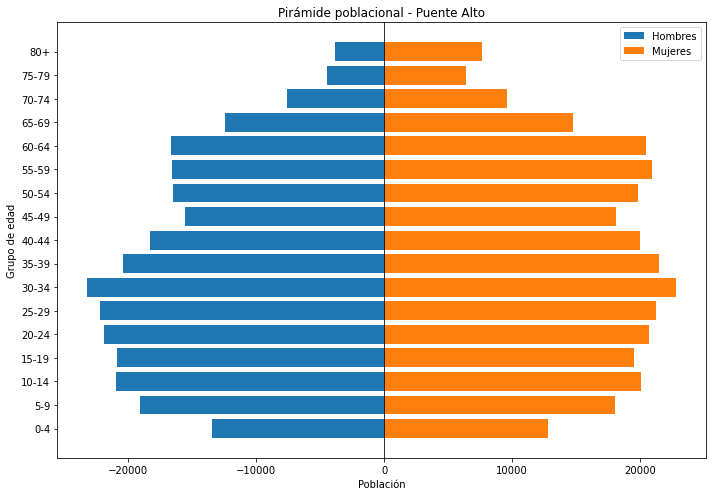

In [9]:
# 1 = hombre, 2 = mujer
pyramid = (
    df_work.groupby(["age_group", "sexo"])
    .size()
    .unstack(fill_value=0)
    .reindex(labels)
)

if 1 in pyramid.columns:
    pyramid[1] = -pyramid[1]

plt.figure(figsize=(10, 7))
plt.barh(pyramid.index, pyramid.get(1, pd.Series(0, index=pyramid.index)), label="Hombres")
plt.barh(pyramid.index, pyramid.get(2, pd.Series(0, index=pyramid.index)), label="Mujeres")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Pirámide poblacional - Puente Alto")
plt.xlabel("Población")
plt.ylabel("Grupo de edad")
plt.legend()
plt.tight_layout()
plt.show()

Se analiza la cantidad de personas por hogar para identificar la estructura familiar predominante en la comuna.

/var/folders/9q/3_p5btzj6m314z8dw2jb1b040000gn/T/ipykernel_21444/70592485.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_pyr.groupby(["age_group", "sexo", "p25_lug_nacimiento_rec"])


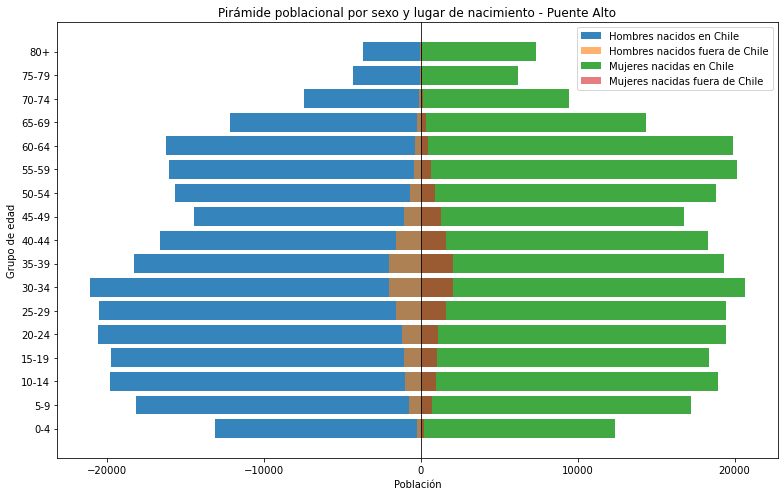

In [10]:
# p25_lug_nacimiento_rec: 1 = nació en Chile, 2 = no
df_pyr = df_work[df_work["p25_lug_nacimiento_rec"].isin([1, 2])].copy()

pyr_birth = (
    df_pyr.groupby(["age_group", "sexo", "p25_lug_nacimiento_rec"])
    .size()
    .reset_index(name="n")
)

male_ch = pyr_birth[(pyr_birth["sexo"] == 1) & (pyr_birth["p25_lug_nacimiento_rec"] == 1)].set_index("age_group")["n"].reindex(labels, fill_value=0)
male_for = pyr_birth[(pyr_birth["sexo"] == 1) & (pyr_birth["p25_lug_nacimiento_rec"] == 2)].set_index("age_group")["n"].reindex(labels, fill_value=0)
fem_ch = pyr_birth[(pyr_birth["sexo"] == 2) & (pyr_birth["p25_lug_nacimiento_rec"] == 1)].set_index("age_group")["n"].reindex(labels, fill_value=0)
fem_for = pyr_birth[(pyr_birth["sexo"] == 2) & (pyr_birth["p25_lug_nacimiento_rec"] == 2)].set_index("age_group")["n"].reindex(labels, fill_value=0)

plt.figure(figsize=(11, 7))
plt.barh(labels, -male_ch, label="Hombres nacidos en Chile", alpha=0.9)
plt.barh(labels, -male_for, label="Hombres nacidos fuera de Chile", alpha=0.6)
plt.barh(labels, fem_ch, label="Mujeres nacidas en Chile", alpha=0.9)
plt.barh(labels, fem_for, label="Mujeres nacidas fuera de Chile", alpha=0.6)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Pirámide poblacional por sexo y lugar de nacimiento - Puente Alto")
plt.xlabel("Población")
plt.ylabel("Grupo de edad")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
young = df_work[df_work["edad"] <= 14].shape[0]
old = df_work[df_work["edad"] >= 65].shape[0]
working = df_work[(df_work["edad"] >= 15) & (df_work["edad"] <= 64)].shape[0]

dependency_ratio = (young + old) / working if working > 0 else np.nan

dep_table = pd.DataFrame({
    "comuna": [13201],
    "dependency_ratio": [dependency_ratio]})

dep_table

,comuna,dependency_ratio
0,13201,0.430302


Se analiza el promedio de años de escolaridad en la población adulta, diferenciando según lugar de nacimiento.

In [12]:
household_size = (
    df.groupby(["id_vivienda", "id_hogar"])["id_persona"]
    .nunique()
    .reset_index(name="household_size")
)

household_size["size_cat"] = household_size["household_size"].clip(upper=8)
household_size["size_cat"] = household_size["size_cat"].astype(str).replace("8", "8+")

hh_dist = household_size["size_cat"].value_counts().sort_index()
hh_dist

size_cat
1     28026
2     43506
3     45291
4     37796
5     17874
6      6787
7      2576
8+     1759
Name: count, dtype: int64

Se analiza la participación en la fuerza de trabajo de la población en edad laboral.

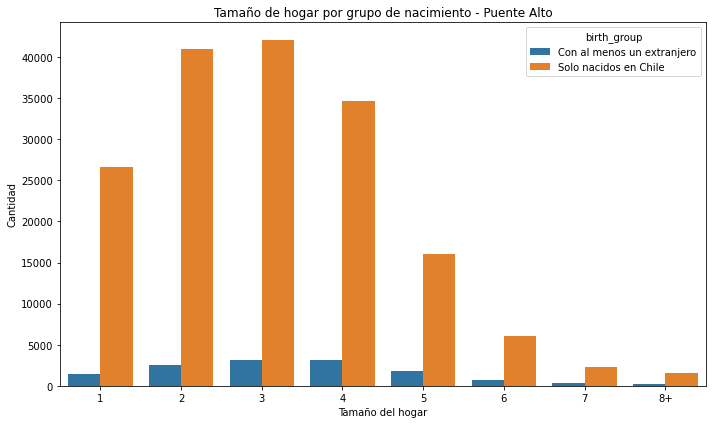

In [14]:
order = [str(i) for i in range(1, 8)] + ["8+"]

hh_birth = (
    df.groupby(["id_vivienda", "id_hogar"])["p25_lug_nacimiento_rec"]
    .apply(lambda s: "Con al menos un extranjero" if (s == 2).any() else "Solo nacidos en Chile")
    .reset_index(name="birth_group"))

household_size2 = household_size.merge(
    hh_birth,
    on=["id_vivienda", "id_hogar"],
    how="left")

hh_birth_plot = (
    household_size2.groupby(["size_cat", "birth_group"], dropna=False)
    .size()
    .reset_index(name="n"))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=hh_birth_plot,
    x="size_cat",
    y="n",
    hue="birth_group",
    order=order)
plt.title("Tamaño de hogar por grupo de nacimiento - Puente Alto")
plt.xlabel("Tamaño del hogar")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

Se calcula la proporción de población extranjera en la comuna para dimensionar la magnitud del fenómeno migratorio.

In [15]:
# escolaridad 25+
school_df = df_work[
    (df_work["edad"] >= 25) &
    (df_work["escolaridad"].notna()) &
    (df_work["p25_lug_nacimiento_rec"].isin([1, 2]))].copy()

school_stats = (
    school_df.groupby("p25_lug_nacimiento_rec")["escolaridad"]
    .mean()
    .reset_index()
)

school_stats["grupo"] = school_stats["p25_lug_nacimiento_rec"].map({
    1: "Nacidos en Chile",
    2: "Nacidos fuera de Chile"
})

school_stats

,p25_lug_nacimiento_rec,escolaridad,grupo
0,1.0,12.119722,Nacidos en Chile
1,2.0,12.678511,Nacidos fuera de Chile


In [17]:
# empleo 15-64
# sit_fuerza_trabajo = 1 ocupado, 2 desocupado, 3 fuera de la fuerza
emp_df = df_work[
    (df_work["edad"] >= 15) &
    (df_work["edad"] <= 64) &
    (df_work["sit_fuerza_trabajo"].notna()) &
    (df_work["p25_lug_nacimiento_rec"].isin([1, 2]))
].copy()

emp_df["empleado"] = (emp_df["sit_fuerza_trabajo"] == 1).astype(int)

emp_stats = (
    emp_df.groupby("p25_lug_nacimiento_rec")["empleado"]
    .mean()
    .reset_index()
)

emp_stats["grupo"] = emp_stats["p25_lug_nacimiento_rec"].map({
    1: "Nacidos en Chile",
    2: "Nacidos fuera de Chile"
})

emp_stats

,p25_lug_nacimiento_rec,empleado,grupo
0,1.0,0.623999,Nacidos en Chile
1,2.0,0.718705,Nacidos fuera de Chile


Se identifican las nacionalidades más frecuentes entre la población nacida fuera de Chile.

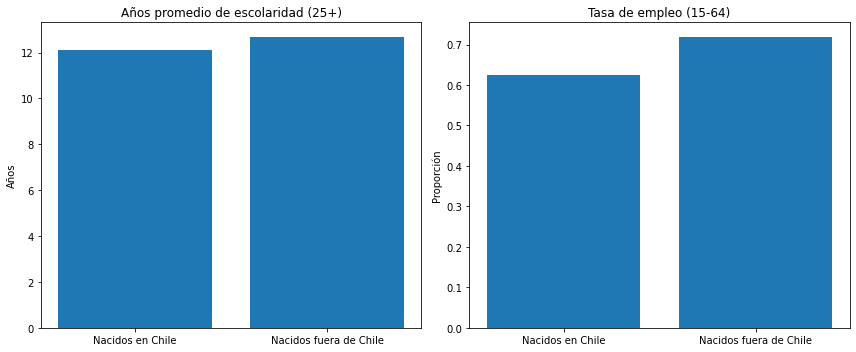

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(school_stats["grupo"], school_stats["escolaridad"])
axes[0].set_title("Años promedio de escolaridad (25+)")
axes[0].set_ylabel("Años")

axes[1].bar(emp_stats["grupo"], emp_stats["empleado"])
axes[1].set_title("Tasa de empleo (15-64)")
axes[1].set_ylabel("Proporción")

plt.tight_layout()
plt.show()

Se analiza el lugar de residencia de las personas hace cinco años para identificar patrones de movilidad reciente.

In [19]:
print("Dependency ratio:", dependency_ratio)
print("\nEscolaridad:")
print(school_stats[["grupo", "escolaridad"]])
print("\nEmpleo:")
print(emp_stats[["grupo", "empleado"]])

Dependency ratio: 0.43030220631000127

Escolaridad:
                    grupo  escolaridad
0        Nacidos en Chile    12.119722
1  Nacidos fuera de Chile    12.678511

Empleo:
                    grupo  empleado
0        Nacidos en Chile  0.623999
1  Nacidos fuera de Chile  0.718705


Se estudia el momento de llegada al país de la población extranjera para identificar si la migración es reciente o de larga data.

In [20]:
mig_df = df.copy().replace(-99, np.nan)

mig_valid = mig_df[mig_df["p25_lug_nacimiento_rec"].isin([1, 2])].copy()

pop_total = len(mig_valid)
pop_chile = (mig_valid["p25_lug_nacimiento_rec"] == 1).sum()
pop_foreign = (mig_valid["p25_lug_nacimiento_rec"] == 2).sum()
pct_foreign = pop_foreign / pop_total if pop_total > 0 else np.nan

pct_table = pd.DataFrame({
    "comuna": [13201],
    "pop_total": [pop_total],
    "pop_chilean": [pop_chile],
    "pop_foreign": [pop_foreign],
    "pct_foreign": [pct_foreign]
})

pct_table

,comuna,pop_total,pop_chilean,pop_foreign,pct_foreign
0,13201,564477,534717,29760,0.052721


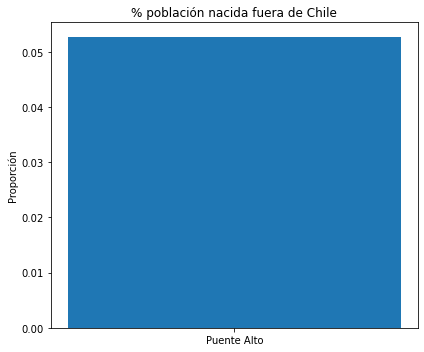

In [21]:
plt.figure(figsize=(6, 5))
plt.bar(["Puente Alto"], [pct_foreign])
plt.title("% población nacida fuera de Chile")
plt.ylabel("Proporción")
plt.tight_layout()
plt.show()

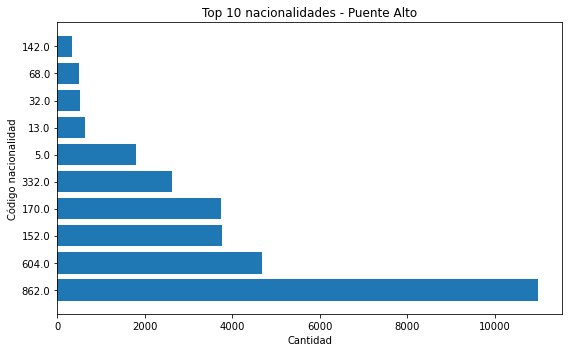

In [22]:
top_nat = (
    mig_valid[mig_valid["p25_lug_nacimiento_rec"] == 2]["p27_nacionalidad_esp"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_nat.columns = ["codigo_nacionalidad", "n"]
top_nat
plt.figure(figsize=(8, 5))
plt.barh(top_nat["codigo_nacionalidad"].astype(str), top_nat["n"])
plt.title("Top 10 nacionalidades - Puente Alto")
plt.xlabel("Cantidad")
plt.ylabel("Código nacionalidad")
plt.tight_layout()
plt.show()

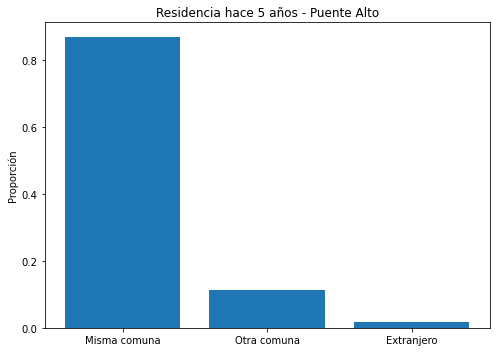

In [23]:
res5_df = mig_df[
    (mig_df["edad"].notna()) &
    (mig_df["edad"] >= 5) &
    (mig_df["p24_lug_resid5"].isin([2, 3, 4]))
].copy()
res5_map_simple = {
    2: "Misma comuna",
    3: "Otra comuna",
    4: "Extranjero"
}

res5_df["resid5_group"] = res5_df["p24_lug_resid5"].map(res5_map_simple)

res5_stats = (
    res5_df["resid5_group"]
    .value_counts(normalize=True)
    .reset_index()
)

res5_stats.columns = ["grupo", "share"]
res5_stats
plt.figure(figsize=(7, 5))
plt.bar(res5_stats["grupo"], res5_stats["share"])
plt.title("Residencia hace 5 años - Puente Alto")
plt.ylabel("Proporción")
plt.tight_layout()
plt.show()

Se construye una tabla con indicadores clave que sintetizan los principales resultados del análisis.

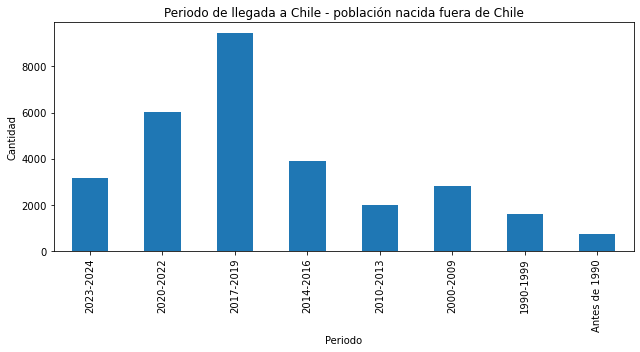

In [24]:
arrival_df = mig_valid[
    (mig_valid["p25_lug_nacimiento_rec"] == 2) &
    (mig_valid["p26_llegada_periodo"].isin([1,2,3,4,5,6,7,8]))
].copy()

arrival_map = {
    1: "2023-2024",
    2: "2020-2022",
    3: "2017-2019",
    4: "2014-2016",
    5: "2010-2013",
    6: "2000-2009",
    7: "1990-1999",
    8: "Antes de 1990"
}

arrival_df["arrival_period"] = arrival_df["p26_llegada_periodo"].map(arrival_map)

arrival_stats = (
    arrival_df["arrival_period"]
    .value_counts()
    .reindex([
        "2023-2024", "2020-2022", "2017-2019", "2014-2016",
        "2010-2013", "2000-2009", "1990-1999", "Antes de 1990"
    ], fill_value=0)
)

arrival_stats
plt.figure(figsize=(9, 5))
arrival_stats.plot(kind="bar")
plt.title("Periodo de llegada a Chile - población nacida fuera de Chile")
plt.xlabel("Periodo")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

Se incorpora información geográfica para representar espacialmente los indicadores construidos.

In [25]:
print("Población total válida:", pop_total)
print("Población nacida en Chile:", pop_chile)
print("Población nacida fuera de Chile:", pop_foreign)
print("Porcentaje nacida fuera de Chile:", round(pct_foreign * 100, 2), "%")

Población total válida: 564477
Población nacida en Chile: 534717
Población nacida fuera de Chile: 29760
Porcentaje nacida fuera de Chile: 5.27 %


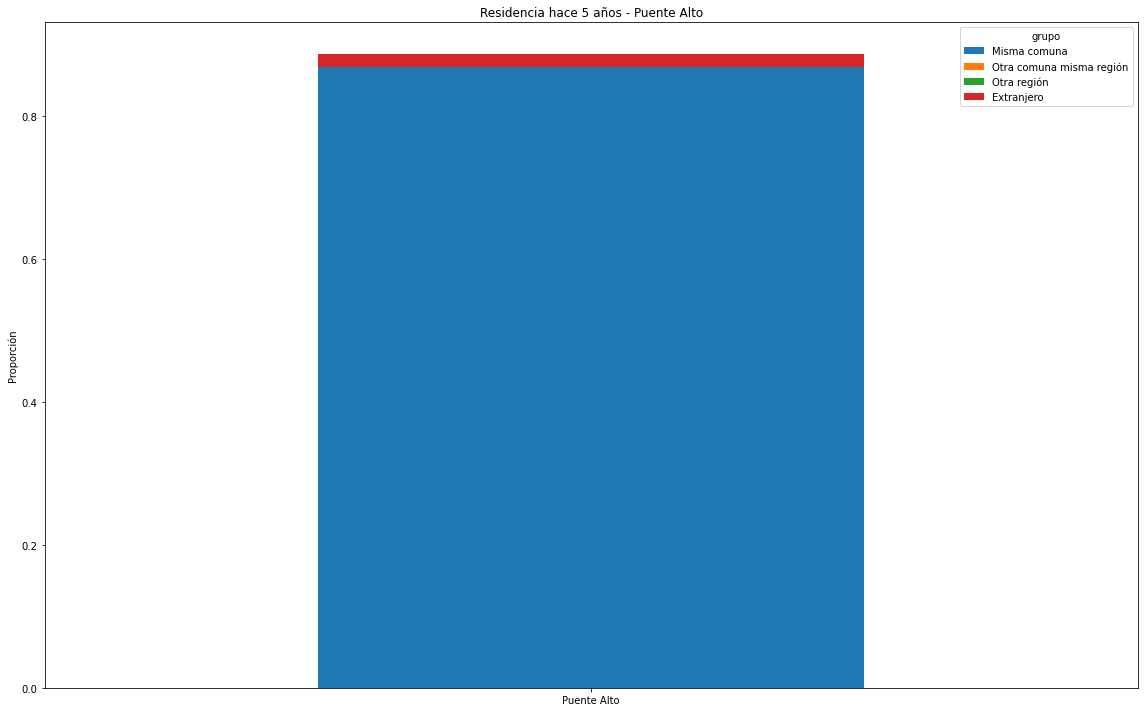

In [26]:
persona = pd.read_parquet(
    f"{BASE}/personas_censo2024.parquet",
    columns=[
        "id_vivienda",
        "id_hogar",
        "id_persona",
        "sexo",
        "edad",
        "p27_nacionalidad_esp",
        "p25_lug_nacimiento_rec",
        "p24_lug_resid5",
        "p24_lug_resid5_esp",
        "p25_lug_nacimiento",
        "p26_llegada_periodo",
        "escolaridad",
        "cine11",
        "sit_fuerza_trabajo",
        "cod_ciuo",
        "cod_caenes",
        "p45_medio_transporte",
        "comuna",
        "region"
    ])
viv = vivienda[vivienda["comuna"].isin(MY_COMUNAS)].copy()
hog = hogar[hogar["id_vivienda"].isin(viv["id_vivienda"])].copy()
per = persona[persona["id_vivienda"].isin(viv["id_vivienda"])].copy()

df = per.merge(
    hog,
    on=["id_vivienda", "id_hogar"],
    how="left"
).merge(
    viv,
    on="id_vivienda",
    how="left",
    suffixes=("_per", "_viv")
)

assert len(df) == len(per), "Row count mismatch after join!"
mig_df = df.copy().replace(-99, np.nan)
res5_df = mig_df[
    (mig_df["edad"].notna()) &
    (mig_df["edad"] >= 5) &
    (mig_df["p24_lug_resid5"].notna())
].copy()
def classify_resid5(row):
    p24 = row["p24_lug_resid5"]
    esp = row["p24_lug_resid5_esp"]
    current_region = row["region_per"] if "region_per" in row.index else row["region"]
    
    if pd.isna(p24):
        return np.nan
    
    if p24 == 2:
        return "Misma comuna"
    
    if p24 == 4:
        return "Extranjero"
    
    if p24 == 3:
        if pd.isna(esp):
            return np.nan
        
        # si esp es código territorial chileno, la región se obtiene truncando /1000
        past_region = int(esp) // 1000
        
        if past_region == current_region:
            return "Otra comuna misma región"
        else:
            return "Otra región"
    
    return np.nan
res5_df["resid5_group"] = res5_df.apply(classify_resid5, axis=1)
res5_stacked = pd.DataFrame({
    "Puente Alto": res5_stats.set_index("grupo")["share"]
}).T

res5_stacked = res5_stacked.reindex(
    columns=[
        "Misma comuna",
        "Otra comuna misma región",
        "Otra región",
        "Extranjero"
    ],
    fill_value=0)

res5_stacked.plot(kind="bar", stacked=True, figsize=(16,10))
plt.title("Residencia hace 5 años - Puente Alto")
plt.ylabel("Proporción")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Se representa espacialmente la población total de la comuna.

In [27]:
print(res5_df["resid5_group"].value_counts(dropna=False))

resid5_group
Misma comuna                467082
Otra comuna misma región     52828
Extranjero                    9846
Otra región                   7648
NaN                            137
Name: count, dtype: int64


Se representa el porcentaje de población nacida fuera de Chile en la comuna.

In [29]:
def build_summary(group):
    g = group.copy().replace(-99, np.nan)

    # válidos para nacimiento
    g_birth = g[g["p25_lug_nacimiento_rec"].isin([1, 2])].copy()

    pop_total = len(g_birth)
    pop_chilean = (g_birth["p25_lug_nacimiento_rec"] == 1).sum()
    pop_foreign = (g_birth["p25_lug_nacimiento_rec"] == 2).sum()
    pct_foreign = pop_foreign / pop_total if pop_total > 0 else np.nan

    median_age_chilean = g_birth.loc[
        (g_birth["p25_lug_nacimiento_rec"] == 1) & (g_birth["edad"].notna()),
        "edad"
    ].median()

    median_age_foreign = g_birth.loc[
        (g_birth["p25_lug_nacimiento_rec"] == 2) & (g_birth["edad"].notna()),
        "edad"
    ].median()

    mean_schooling_chilean = g_birth.loc[
        (g_birth["p25_lug_nacimiento_rec"] == 1) &
        (g_birth["edad"] >= 25) &
        (g_birth["escolaridad"].notna()),
        "escolaridad"
    ].mean()

    mean_schooling_foreign = g_birth.loc[
        (g_birth["p25_lug_nacimiento_rec"] == 2) &
        (g_birth["edad"] >= 25) &
        (g_birth["escolaridad"].notna()),
        "escolaridad"
    ].mean()

    emp_rate_chilean = (
        g_birth.loc[
            (g_birth["p25_lug_nacimiento_rec"] == 1) &
            (g_birth["edad"] >= 15) &
            (g_birth["edad"] <= 64) &
            (g_birth["sit_fuerza_trabajo"].notna()),
            "sit_fuerza_trabajo"
        ].eq(1).mean()
    )

    emp_rate_foreign = (
        g_birth.loc[
            (g_birth["p25_lug_nacimiento_rec"] == 2) &
            (g_birth["edad"] >= 15) &
            (g_birth["edad"] <= 64) &
            (g_birth["sit_fuerza_trabajo"].notna()),
            "sit_fuerza_trabajo"
        ].eq(1).mean()
    )

    g_age = g[g["edad"].notna()].copy()
    young = (g_age["edad"] <= 14).sum()
    old = (g_age["edad"] >= 65).sum()
    working = ((g_age["edad"] >= 15) & (g_age["edad"] <= 64)).sum()
    dependency_ratio = (young + old) / working if working > 0 else np.nan

    return pd.Series({
        "codigo_comuna": g["comuna_per"].dropna().iloc[0] if "comuna_per" in g.columns else g["comuna"].dropna().iloc[0],
        "nombre_comuna": "Puente Alto",
        "pop_total": pop_total,
        "pop_chilean": pop_chilean,
        "pop_foreign": pop_foreign,
        "pct_foreign": pct_foreign,
        "median_age_chilean": median_age_chilean,
        "median_age_foreign": median_age_foreign,
        "mean_schooling_chilean": mean_schooling_chilean,
        "mean_schooling_foreign": mean_schooling_foreign,
        "emp_rate_chilean": emp_rate_chilean,
        "emp_rate_foreign": emp_rate_foreign,
        "dependency_ratio": dependency_ratio
    })
summary = (
    df.groupby("comuna_per")
    .apply(build_summary)
    .reset_index(drop=True))

summary
import os

output_dir = f"{BASE}/output"
os.makedirs(output_dir, exist_ok=True)

summary.to_csv(f"{output_dir}/tarea1_comuna_summary.csv", index=False)
print("Guardado en:", f"{output_dir}/tarea1_comuna_summary.csv")

Guardado en: /Users/martingomez/Downloads/viv_hog_per_censo2024/output/tarea1_comuna_summary.csv


/var/folders/9q/3_p5btzj6m314z8dw2jb1b040000gn/T/ipykernel_21444/2921339515.py:78: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("comuna_per")


In [30]:
comunas_gdf = gpd.read_file("/Users/martingomez/Downloads/comunas.shp")
print(comunas_gdf.columns.tolist())
print(comunas_gdf.head())

['objectid', 'shape_leng', 'dis_elec', 'cir_sena', 'cod_comuna', 'codregion', 'st_area_sh', 'st_length_', 'Region', 'Comuna', 'Provincia', 'geometry']
   objectid     shape_leng  dis_elec  cir_sena  cod_comuna  codregion  \
0        48  170038.624165        16         8        6204          6   
1        29  125730.104795        15         8        6102          6   
2        30   63026.084422        15         8        6103          6   
3        31   89840.903562        15         8        6104          6   
4        78  122626.493264        23        11        9121          9   

     st_area_sh     st_length_                                    Region  \
0  9.685774e+08  206184.271675  Región del Libertador Bernardo O'Higgins   
1  4.157446e+08  151911.576827  Región del Libertador Bernardo O'Higgins   
2  1.448565e+08   76355.326122  Región del Libertador Bernardo O'Higgins   
3  3.256572e+08  108874.623150  Región del Libertador Bernardo O'Higgins   
4  6.990727e+08  156680.410681

In [31]:
possible_code_cols = [
    "comuna", "COMUNA", "codigo_comuna", "COD_COMUNA",
    "CUT_COM", "CUT_COMUNA", "cod_comuna"
]

code_col = None
for c in possible_code_cols:
    if c in comunas_gdf.columns:
        code_col = c
        break

print("Columna código detectada:", code_col)

Columna código detectada: cod_comuna


In [32]:
summary_map = summary.copy()
summary_map["codigo_comuna"] = pd.to_numeric(summary_map["codigo_comuna"], errors="coerce")

comunas_gdf["cod_comuna"] = pd.to_numeric(comunas_gdf["cod_comuna"], errors="coerce")

mapa = comunas_gdf.merge(
    summary_map,
    left_on="cod_comuna",
    right_on="codigo_comuna",
    how="inner"
)

print(mapa.shape)
mapa.head()

(1, 25)


,objectid,shape_leng,dis_elec,cir_sena,cod_comuna,codregion,st_area_sh,st_length_,Region,Comuna,...,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,emp_rate_foreign,dependency_ratio
0,292,48961.65484,12,7,13201,13,1.269446e+08,58874.136921,Región Metropolitana de Santiago,Puente Alto,...,534717,29760,0.052721,35.0,34.0,12.119722,12.678511,0.623999,0.718705,0.430302


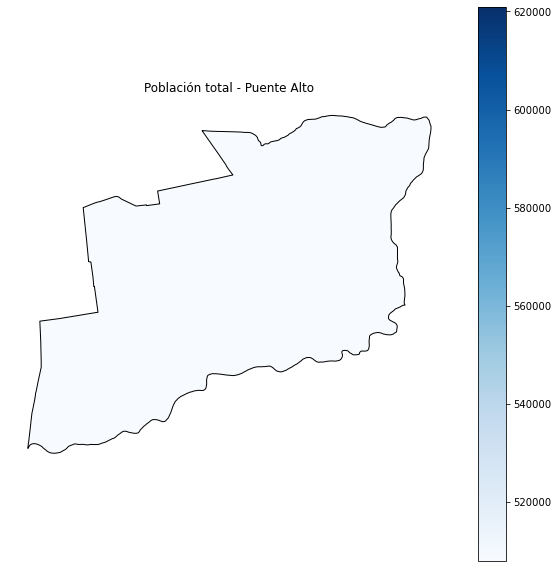

In [33]:
fig, ax = plt.subplots(figsize=(8, 8))
mapa.plot(
    column="pop_total",
    cmap="Blues",
    legend=True,
    edgecolor="black",
    ax=ax
)
ax.set_title("Población total - Puente Alto")
ax.axis("off")
plt.tight_layout()
plt.show()

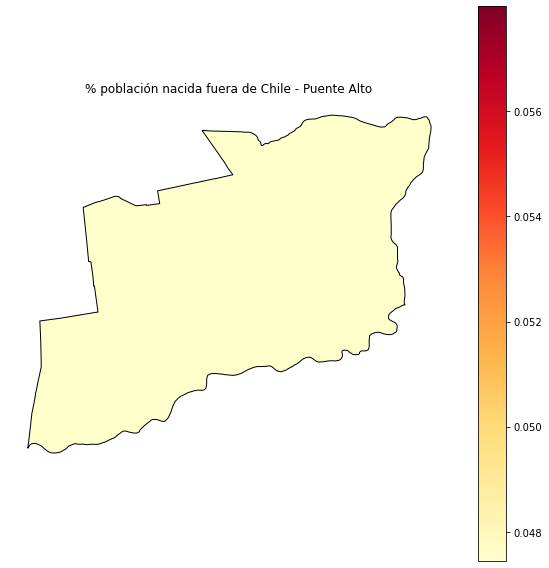

In [34]:
fig, ax = plt.subplots(figsize=(8, 8))
mapa.plot(
    column="pct_foreign",
    cmap="YlOrRd",
    legend=True,
    edgecolor="black",
    ax=ax
)
ax.set_title("% población nacida fuera de Chile - Puente Alto")
ax.axis("off")
plt.tight_layout()
plt.show()

El análisis de la comuna de Puente Alto permite identificar una población relativamente joven, con una estructura de hogares tradicional y una presencia migrante relevante.

Estos resultados permiten comprender de mejor manera la dinámica demográfica y social de la comuna.